### Predictive Analysis — Healthcare Appointment No-show Prediction

**Stage 2 of the project roadmap: Predictive Analytics.**

This notebook picks up where `01_analysis.ipynb` left off. That notebook explored the data
descriptively; This one builds and compares three predictive models — Logistic Regression, Decision Tree and Random Forest — to answer a forward-looking question:

> **Business question:** Given information available before an appointment happens, what is the predicted probability that the patient will not show up?

**Target definition**:
- `No-show` → **1**
- `Completed` or `Cancelled` → **0**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## Data Preprocessing
### 1. Load the Clean Dataset

`01_analysis.ipynb` cleans the raw `data/appointments.csv` (renames `specialty` →
`doctor_specialty`, checks for missing values — there are none) and derives an `age_group`
column. To keep the two notebooks independent, that cleaning logic — plus the binary
`is_no_show` target this project needs — has been extracted and saved once as
**`data/appointments_clean.csv`**. This notebook loads that file directly instead of
recomputing the cleaning steps or touching `01_analysis.ipynb`.

`is_no_show` is built the same way the Stage 1 no-show-rate analysis defines a no-show:
`appointment_status == 'No-show'` → `1`, otherwise → `0`.


In [2]:
df = pd.read_csv('../data/appointments_clean.csv', parse_dates=['appointment_date'])

print("=== Dataset Overview ===")
print(f"Rows, Columns : {df.shape}")
print(f"Date Range    : {df['appointment_date'].min().date()} → {df['appointment_date'].max().date()}\n")

print("=== Columns & Types ===")
print(df.dtypes)

df.head()


=== Dataset Overview ===
Rows, Columns : (500, 12)
Date Range    : 2023-01-02 → 2024-12-26

=== Columns & Types ===
patient_age                      int64
patient_gender                  object
division                        object
doctor_specialty                object
appointment_status              object
consultation_fee_bdt             int64
wait_days                        int64
appointment_date        datetime64[ns]
age_group                       object
month                            int64
year                             int64
month_name                      object
dtype: object


,patient_age,patient_gender,division,doctor_specialty,appointment_status,consultation_fee_bdt,wait_days,appointment_date,age_group,month,year,month_name
0,56,Female,Chattogram,Gynecologist,Completed,914,4,2023-11-19,Senior (56+),11,2023,Nov
1,19,Male,Barishal,Cardiologist,Completed,1546,6,2024-06-07,Young Adult (18-35),6,2024,Jun
2,76,Female,Dhaka,Pediatrician,Completed,725,1,2023-02-27,Senior (56+),2,2023,Feb
3,65,Male,Chattogram,Cardiologist,Completed,1492,20,2024-03-17,Senior (56+),3,2024,Mar
4,25,Male,Dhaka,Orthopedic,Cancelled,1331,16,2023-04-06,Young Adult (18-35),4,2023,Apr


### 2. Feature Engineering 

The raw date itself isn't a usable model input (a `LogisticRegression` can't do anything
meaningful with a timestamp). Instead extracting three interpretable,
recurring signals from it, as required:

- **Quarter** (`Q1`–`Q4`) — a coarse seasonality signal (e.g. holiday season, weather patterns).
- **Day of week** (Sunday/Monday/..).
- **Day type** (Weekday / Weekend).


In [3]:
BD_WEEKEND_DAYS = {'Friday', 'Saturday'}  # Bangladesh's official weekend

df['quarter'] = 'Q' + df['appointment_date'].dt.quarter.astype(str)
df['day_of_week'] = df['appointment_date'].dt.day_name()
df['day_type'] = np.where(df['day_of_week'].isin(BD_WEEKEND_DAYS), 'Weekend', 'Weekday')

print("=== Sample of engineered date features ===")
df[['appointment_date', 'quarter', 'day_of_week', 'day_type']].head(8)

=== Sample of engineered date features ===


,appointment_date,quarter,day_of_week,day_type
0,2023-11-19,Q4,Sunday,Weekday
1,2024-06-07,Q2,Friday,Weekend
2,2023-02-27,Q1,Monday,Weekday
3,2024-03-17,Q1,Sunday,Weekday
4,2023-04-06,Q2,Thursday,Weekday
5,2023-11-19,Q4,Sunday,Weekday
6,2024-05-24,Q2,Friday,Weekend
7,2023-09-06,Q3,Wednesday,Weekday


In [4]:
# ── Build the Target: is_no_show ─────────────────────────────────────────────
df['is_no_show'] = (df['appointment_status'] == 'No-show').astype(int)

print("=== Target Balance (is_no_show) ===")
print(df['is_no_show'].value_counts())
print(df['is_no_show'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== Target Balance (is_no_show) ===
is_no_show
0    444
1     56
Name: count, dtype: int64
is_no_show
0    88.8%
1    11.2%
Name: proportion, dtype: object


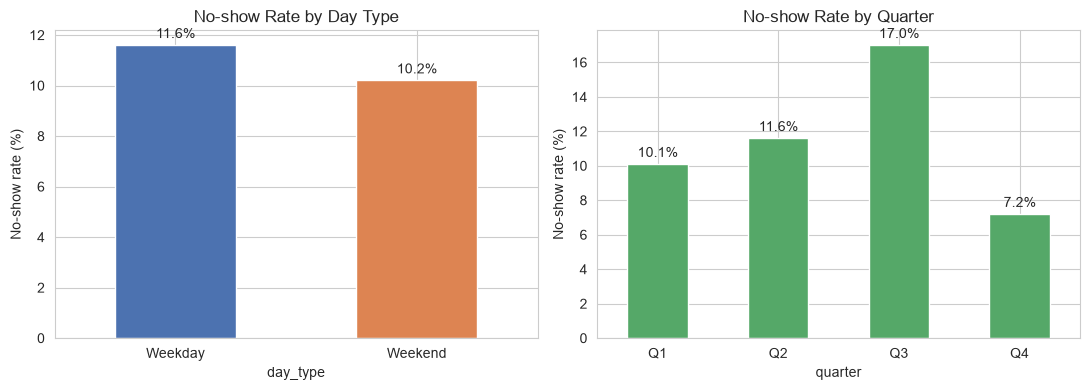

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

day_type_rate = df.groupby('day_type')['is_no_show'].mean().mul(100).round(1)
day_type_rate.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', padding=3)
axes[0].set_title('No-show Rate by Day Type')
axes[0].set_ylabel('No-show rate (%)')
axes[0].tick_params(axis='x', rotation=0)

quarter_rate = df.groupby('quarter')['is_no_show'].mean().mul(100).round(1).sort_index()
quarter_rate.plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=3)
axes[1].set_title('No-show Rate by Quarter')
axes[1].set_ylabel('No-show rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3. Feature Selection — Avoiding Data Leakage

**Data leakage** happens when a feature contains information that wouldn't actually be
available *before* the event you're predicting — the model looks accurate in testing but is
useless in production because that information doesn't exist yet at prediction time.

Going through every column in the clean dataset:

| Column | Use as a feature? | Reason |
|---|---|---|
| `appointment_status` | ❌ **Excluded** | This is literally how the target was built (`is_no_show`). Using it as a feature would leak the answer directly — the model would just learn "No-show" → predict No-show. |
| `is_no_show` | ❌ Target, not a feature | What we're predicting. |
| `consultation_fee_bdt` | ❌ **Excluded per project requirement** | Excluded deliberately for this stage. As a side note, it's also almost a 1:1 stand-in for `doctor_specialty` (each specialty has a near-fixed fee band), so keeping both would add redundant. |
| `appointment_date` (raw) | ❌ Excluded | Replaced by the engineered `quarter` / `day_of_week` / `day_type` features above. |
| `age_group` | ❌ Excluded | Directly derived from `patient_age` (just a binned version of it). Keeping both would be redundant; `patient_age` as a continuous number gives the model more granular information than a 4-bucket version of the same thing. |
| `month` | ❌ Excluded | Numeric duplicate of `month_name` |
| `year` | ❌ Excluded | Both years present (2023, 2024) are already in the past. Once this model is used going forward, every new appointment will carry a year (2025, 2026, ...) the model has never seen during training, so any pattern it learned tied to a specific year value simply won't transfer. |
| `patient_age` | ✅ Included | Known at booking time. |
| `patient_gender` | ✅ Included | Known at booking time. |
| `division` | ✅ Included | Known at booking time. |
| `doctor_specialty` | ✅ Included | Known at booking time. |
| `wait_days` | ✅ Included | This is the gap between *booking* and the *appointment date* — it's set the moment the appointment is scheduled, so it's fully known in advance. Not leakage. |
| `quarter`, `day_of_week`, `day_type`, `month_name` | ✅ Included | Derived from the appointment date, which is scheduled in advance. |


In [6]:
categorical_features = [
    'patient_gender', 'division', 'doctor_specialty', 'month_name',
    'quarter', 'day_of_week', 'day_type'
]
numerical_features = ['patient_age', 'wait_days']

feature_cols = categorical_features + numerical_features

X = df[feature_cols]
Y = df['is_no_show']

print("Final feature set:")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical   ({len(numerical_features)}): {numerical_features}")
print(f"\nX shape: {X.shape}   Y shape: {Y.shape}")


Final feature set:
  Categorical (7): ['patient_gender', 'division', 'doctor_specialty', 'month_name', 'quarter', 'day_of_week', 'day_type']
  Numerical   (2): ['patient_age', 'wait_days']

X shape: (500, 9)   Y shape: (500,)


### 4. Train/Test Split 

With only 56 no-show cases in 500 rows, a plain random split risks putting very few no-shows in the test set purely by chance. **`stratify=y`** forces
both the train and test sets to preserve the same ~11.2% no-show ratio as the full dataset, so
the test-set evaluation is a fair reflection of the real class balance.

Splitting is done **before** any encoding or scaling, so the encoder and scaler only ever learn from training data — never from the test set.


In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print(f"Train set: {X_train.shape[0]} rows  |  Test set: {X_test.shape[0]} rows\n")

print("Train target balance:")
print(Y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print("\nTest target balance:")
print(Y_test.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f"\nNo-show cases in test set: {Y_test.sum()} out of {len(Y_test)}")


Train set: 400 rows  |  Test set: 100 rows

Train target balance:
is_no_show
0    88.8%
1    11.2%
Name: proportion, dtype: object

Test target balance:
is_no_show
0    89.0%
1    11.0%
Name: proportion, dtype: object

No-show cases in test set: 11 out of 100


### 5. Preprocessing + Model Pipeline (`ColumnTransformer` + `Pipeline`)

Two preprocessing choices for Logistic Regression specifically:

- **One-hot encoding** for all categorical (nominal) features — Logistic Regression needs
  numeric input, and these categories have no natural order (there's no sense in which
  `division = Dhaka` is "more" than `division = Khulna`). `drop='first'` drops one category per
  feature as a **reference/baseline level**.
- **Standard scaling** for the two numeric features (`patient_age`, `wait_days`) — Scaling puts numerical features on comparable scales and generally makes the optimization process more stable and efficient when learning the coefficients of the equation.

**Avoiding preprocessing leakage:** The encoder and scaler are fitted only on the training data. The test data is then transformed using what was learned from the training data. This prevents information from the test set from influencing the model during training.


In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features),
])

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

lr_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## Model Training

In [9]:
lr_model.fit(X_train, Y_train)
print("Model trained.")

Model trained.


## Learned Coefficients — How to Interpret Them

Logistic Regression learns a coefficient for each feature. These coefficients are used in the z equation to calculate the final probability of No-show.

- Positive coefficient (+) → the feature is associated with higher odds of No-show, while keeping other features constant.
- Negative coefficient (−) → the feature is associated with lower odds of No-show.
- Larger absolute coefficient → stronger effect on the model's calculated odds, although coefficient size should be interpreted carefully across different feature types/scales.

For categorical features, each category is compared with its reference (baseline) category. For example, the reference category for `doctor_specialty` is **Cardiologist** (see the reference categories printed below). So:

Gynecologist coefficient = −0.669 → Gynecologist appointments have lower predicted odds of No-show compared with Cardiologist, holding other features constant.

For scaled numerical features, the coefficient represents the change associated with a one-standard-deviation increase in that variable.


In [10]:
# Reference (dropped) category per categorical feature
fitted_ohe = lr_model.named_steps['preprocessor'].named_transformers_['cat']
print("=== Reference category per feature (dropped by drop='first') ===")
for feat, cats in zip(categorical_features, fitted_ohe.categories_):
    print(f"  {feat:20s} → reference: {cats[0]}")

=== Reference category per feature (dropped by drop='first') ===
  patient_gender       → reference: Female
  division             → reference: Barishal
  doctor_specialty     → reference: Cardiologist
  month_name           → reference: Apr
  quarter              → reference: Q1
  day_of_week          → reference: Friday
  day_type             → reference: Weekday


In [11]:
feature_names = lr_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace('cat__', '').replace('num__', '') for f in feature_names]

coefs = lr_model.named_steps['classifier'].coef_[0]
intercept = lr_model.named_steps['classifier'].intercept_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).reset_index(drop=True)

coef_df

,feature,coefficient
0,day_of_week_Wednesday,-0.759103
1,doctor_specialty_Gynecologist,-0.669278
2,division_Rangpur,-0.642097
3,month_name_May,0.539851
4,day_of_week_Monday,0.495098
5,division_Dhaka,0.482721
6,doctor_specialty_Pediatrician,0.481137
7,day_of_week_Tuesday,0.436862
8,quarter_Q3,0.423667
9,division_Chattogram,0.420507


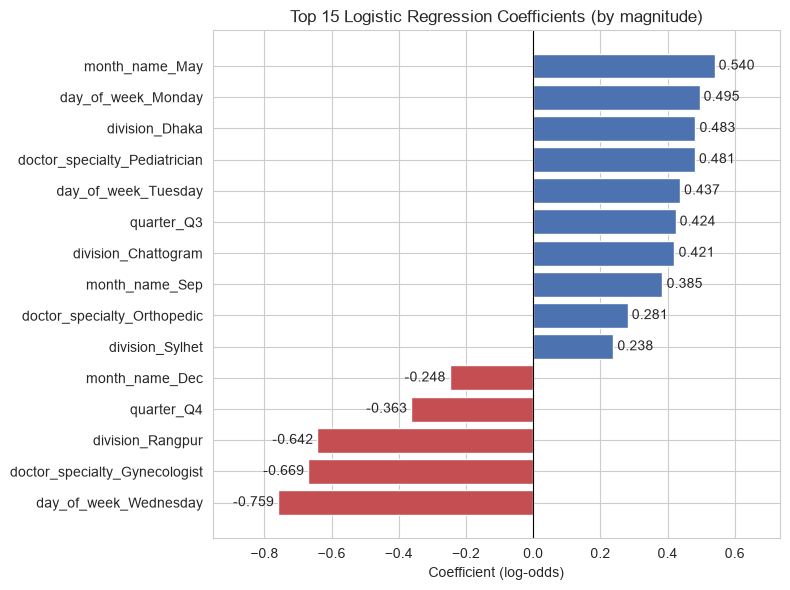

In [12]:
top_n = coef_df.head(15).copy()
top_n = top_n.reindex(top_n['coefficient'].sort_values().index)

fig, ax = plt.subplots(figsize=(8, 6))
ax.margins(x=0.15)
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in top_n['coefficient']]
bars = ax.barh(top_n['feature'], top_n['coefficient'], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 15 Logistic Regression Coefficients (by magnitude)')
plt.tight_layout()
plt.show()

## Predicted Probabilities

Per the business question, the **primary output of this model is a probability**, not a hard
0/1 label. `predict_proba()` returns the probability of both classes.


In [13]:
proba_test = lr_model.predict_proba(X_test)

results = X_test.copy()
results['actual_no_show'] = Y_test.values
results['probability_show'] = proba_test[:, 0].round(3)      
results['probability_no_show'] = proba_test[:, 1].round(3)
results.sort_values('probability_no_show', ascending=False).head(10)

,patient_gender,division,doctor_specialty,month_name,quarter,day_of_week,day_type,patient_age,wait_days,actual_no_show,probability_show,probability_no_show
340,Male,Chattogram,Orthopedic,Sep,Q3,Tuesday,Weekday,46,19,1,0.561,0.439
420,Female,Chattogram,Pediatrician,Sep,Q3,Monday,Weekday,69,8,0,0.651,0.349
19,Male,Dhaka,General Physician,Sep,Q3,Monday,Weekday,62,12,1,0.696,0.304
65,Female,Dhaka,Orthopedic,Sep,Q3,Sunday,Weekday,66,15,0,0.707,0.293
495,Male,Chattogram,Orthopedic,Jun,Q2,Monday,Weekday,11,16,0,0.726,0.274
410,Female,Chattogram,Dermatologist,May,Q2,Tuesday,Weekday,16,13,0,0.746,0.254
123,Female,Rajshahi,Pediatrician,Mar,Q1,Monday,Weekday,33,19,0,0.755,0.245
353,Male,Rajshahi,Orthopedic,Jun,Q2,Monday,Weekday,44,17,0,0.766,0.234
276,Male,Rajshahi,Orthopedic,May,Q2,Monday,Weekday,53,5,0,0.776,0.224
397,Female,Rajshahi,Dermatologist,Jul,Q3,Tuesday,Weekday,38,14,0,0.784,0.216


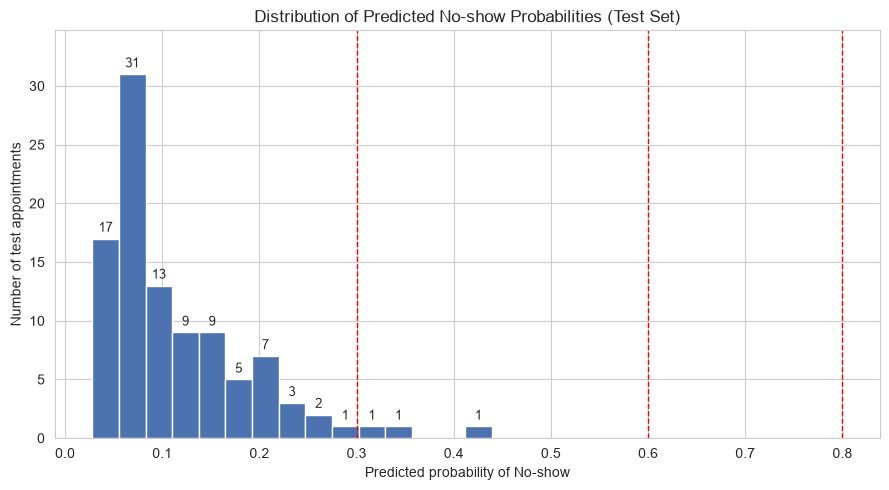

count    100.000
mean       0.115
std        0.076
min        0.028
25%        0.062
50%        0.087
75%        0.156
max        0.439
Name: probability_no_show, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
n, bins, patches = ax.hist(results['probability_no_show'], bins=15, color='#4C72B0', edgecolor='white')

labels = [str(int(count)) if count > 0 else '' for count in n]
ax.bar_label(patches, labels=labels, padding=3, fontsize=9)

for edge, label in zip([0.3, 0.6, 0.8], ['30%', '60%', '80%']):
    ax.axvline(edge, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted probability of No-show')
ax.set_ylabel('Number of test appointments')
ax.set_title('Distribution of Predicted No-show Probabilities (Test Set)')
ax.margins(y=0.12)
plt.tight_layout()
plt.show()

print(pd.Series(results['probability_no_show'], name='probability_no_show').describe().round(3))

## Business Risk Categories

Converting the raw probability into categories a clinic scheduling team can act on, as
specified:

| Probability | Risk Category |
|---|---|
| 0% – 30% | Low |
| 30% – 60% | Moderate |
| 60% – 80% | High |
| 80% – 100% | Very High |


=== Risk Category Counts (Test Set) ===
risk_category
Low          97
Moderate      3
High          0
Very High     0
Name: count, dtype: int64


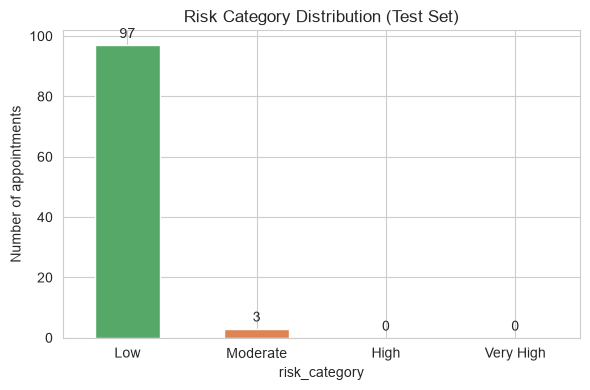

In [15]:
def risk_category(p):
    if p < 0.30:
        return 'Low'
    elif p < 0.60:
        return 'Moderate'
    elif p < 0.80:
        return 'High'
    else:
        return 'Very High'

results['risk_category'] = results['probability_no_show'].apply(risk_category)

category_order = ['Low', 'Moderate', 'High', 'Very High']
risk_counts = results['risk_category'].value_counts().reindex(category_order).fillna(0).astype(int)

print("=== Risk Category Counts (Test Set) ===")
print(risk_counts)

fig, ax = plt.subplots(figsize=(6, 4))
risk_counts.plot(kind='bar', ax=ax, color=['#55A868', '#DD8452', '#C44E52', '#8C0900'])
ax.bar_label(ax.containers[0], padding=3)
ax.set_ylabel('Number of appointments')
ax.set_title('Risk Category Distribution (Test Set)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## Model Evaluation

- **ROC-AUC** — measures how well the model separates No-show appointments from non-No-show appointments based on their predicted probabilities, considering different probability thresholds. 0.5 means the model performs no better than random ranking, while 1.0 means it perfectly separates the two groups.


In [16]:
roc_auc_lr = roc_auc_score(Y_test, results['probability_no_show'])

print(f"ROC-AUC   : {roc_auc_lr:.3f}")

ROC-AUC   : 0.519


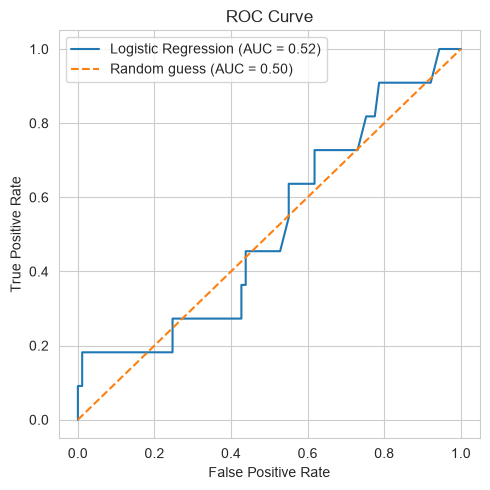

In [17]:
fpr, tpr, _ = roc_curve(Y_test, results['probability_no_show'])

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', label='Random guess (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

plt.tight_layout()
plt.show()

## Model Comparison — Decision Tree & Random Forest

Same features, same train/test split, same preprocessing. Only the classifier changes, so any ROC-AUC difference reflects the model, not the data.

In [18]:
dt_model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ])),
    ('classifier', DecisionTreeClassifier(random_state=42)),
])
dt_model.fit(X_train, Y_train)

proba_dt = dt_model.predict_proba(X_test)[:, 1]
roc_auc_dt = roc_auc_score(Y_test, proba_dt)
print(f"Decision Tree ROC-AUC: {roc_auc_dt:.3f}")

Decision Tree ROC-AUC: 0.563


In [19]:
rf_model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ])),
    ('classifier', RandomForestClassifier(random_state=42)),
])
rf_model.fit(X_train, Y_train)

proba_rf = rf_model.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(Y_test, proba_rf)
print(f"Random Forest ROC-AUC: {roc_auc_rf:.3f}")

Random Forest ROC-AUC: 0.585


In [20]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'ROC-AUC': [roc_auc_lr, roc_auc_dt, roc_auc_rf]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

comparison

,Model,ROC-AUC
0,Random Forest,0.585291
1,Decision Tree,0.563330
2,Logistic Regression,0.519408


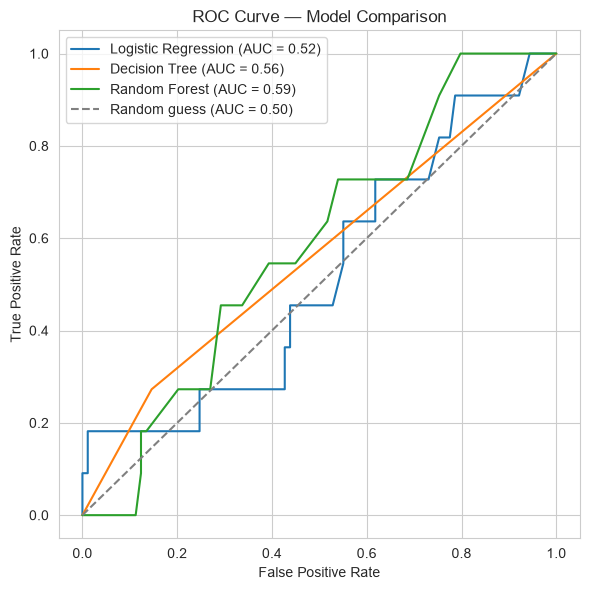

In [21]:
fpr_lr, tpr_lr, _ = roc_curve(Y_test, results['probability_no_show'])
fpr_dt, tpr_dt, _ = roc_curve(Y_test, proba_dt)
fpr_rf, tpr_rf, _ = roc_curve(Y_test, proba_rf)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Random Forest achieved the highest ROC-AUC on the baseline test set (**0.585**), followed by Decision Tree (**0.563**) and Logistic Regression (**0.519**). These results use each model's default settings, evaluated on a single train/test split.

> **Note:** Because the dataset is small, the observed ROC-AUC can vary substantially depending on the train/test split. These baseline results therefore serve as a reference point for evaluating whether hyperparameter tuning improves the models' generalization performance.

## Model Improvement — Class Imbalance Handling & Hyperparameter Tuning

Testing whether `GridSearchCV` hyperparameter tuning (Logistic Regression, Decision Tree, Random Forest) improve on the baseline ROC-AUC scores above.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {
    'classifier__C': [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1],
    'classifier__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    lr_model,
    param_grid_lr,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

grid_lr.fit(X_train, Y_train)

lr_tuned_model = grid_lr.best_estimator_

proba_lr_tuned = lr_tuned_model.predict_proba(X_test)[:, 1]

roc_auc_lr_tuned = roc_auc_score(Y_test, proba_lr_tuned)

print("=== Logistic Regression Tuning Results ===")
print(f"Before Tuning ROC-AUC: {roc_auc_lr:.3f}")
print(f"After Tuning ROC-AUC: {roc_auc_lr_tuned:.3f}")
print(f"Best Parameters: {grid_lr.best_params_}")

=== Logistic Regression Tuning Results ===
Before Tuning ROC-AUC: 0.519
After Tuning ROC-AUC: 0.511
Best Parameters: {'classifier__C': 0.005, 'classifier__class_weight': 'balanced'}


In [23]:
# Decision Tree — GridSearchCV:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_dt = {
    'classifier__max_depth': [3, 5, 6, 7, 8, 10, None],
    'classifier__min_samples_leaf': [2, 3, 5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(dt_model, param_grid_dt, scoring='roc_auc', cv=cv, n_jobs=-1)
grid_dt.fit(X_train, Y_train)

dt_tuned_model = grid_dt.best_estimator_
proba_dt_tuned = dt_tuned_model.predict_proba(X_test)[:, 1]
roc_auc_dt_tuned = roc_auc_score(Y_test, proba_dt_tuned)

print("=== Decision Tree Tuning Results ===")

print(f"Before Tuning ROC-AUC: {roc_auc_dt:.3f}")
print(f"After Tuning ROC-AUC: {roc_auc_dt_tuned:.3f}")
print(f"Best Parameters: {grid_dt.best_params_}")

=== Decision Tree Tuning Results ===
Before Tuning ROC-AUC: 0.563
After Tuning ROC-AUC: 0.532
Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 6, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 2}


In [24]:
# Random Forest — GridSearchCV:
param_grid_rf = {
    'classifier__n_estimators': [80, 90, 100],
    'classifier__max_depth': [6, 7, 8],
    'classifier__min_samples_leaf': [1, 2, 3],
    'classifier__class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(rf_model, param_grid_rf, scoring='roc_auc', cv=cv, n_jobs=-1)
grid_rf.fit(X_train, Y_train)

rf_tuned_model = grid_rf.best_estimator_
proba_rf_tuned = rf_tuned_model.predict_proba(X_test)[:, 1]
roc_auc_rf_tuned = roc_auc_score(Y_test, proba_rf_tuned)

print("=== Random Forest Tuning Results ===")

print(f"Before Tuning ROC-AUC: {roc_auc_rf:.3f}")
print(f"After Tuning ROC-AUC: {roc_auc_rf_tuned:.3f}")
print(f"Best Parameters: {grid_rf.best_params_}")

=== Random Forest Tuning Results ===
Before Tuning ROC-AUC: 0.585
After Tuning ROC-AUC: 0.553
Best Parameters: {'classifier__class_weight': None, 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 90}


In [25]:
improvement_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Baseline ROC-AUC': [roc_auc_lr, roc_auc_dt, roc_auc_rf],
    'Tuned ROC-AUC': [roc_auc_lr_tuned, roc_auc_dt_tuned, roc_auc_rf_tuned],
})
improvement_comparison['Improved?'] = improvement_comparison['Tuned ROC-AUC'] > improvement_comparison['Baseline ROC-AUC']

improvement_comparison

,Model,Baseline ROC-AUC,Tuned ROC-AUC,Improved?
0,Logistic Regression,0.519408,0.510725,False
1,Decision Tree,0.563330,0.532176,False
2,Random Forest,0.585291,0.552605,False


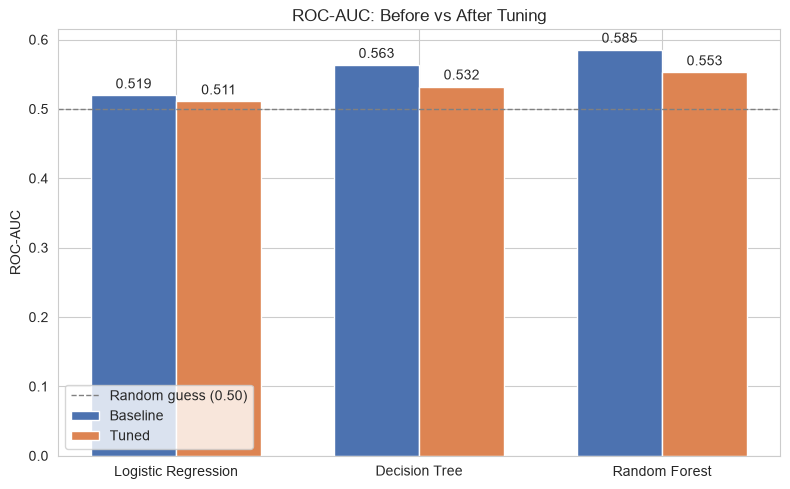

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(improvement_comparison))
width = 0.35

bars_baseline = ax.bar(x - width/2, improvement_comparison['Baseline ROC-AUC'], width, label='Baseline', color='#4C72B0')
bars_tuned = ax.bar(x + width/2, improvement_comparison['Tuned ROC-AUC'], width, label='Tuned', color='#DD8452')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random guess (0.50)')

ax.bar_label(bars_baseline, fmt='%.3f', padding=3)
ax.bar_label(bars_tuned, fmt='%.3f', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(improvement_comparison['Model'])
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC: Before vs After Tuning')
ax.legend()
plt.tight_layout()
plt.show()

## Final Model Selection

The baseline models were first evaluated using one fixed train/test split, with default settings for each classifier. Random Forest achieved the highest ROC-AUC of **0.585**, followed by Decision Tree at **0.563** and Logistic Regression at **0.519**.

The models were then tuned using **cross-validation**. Instead of judging a model from one split, cross-validation tests each model configuration on multiple training and validation splits. This gives a better idea of how consistently the model performs on different data.

After tuning, the test-set ROC-AUC scores were **0.511** for Logistic Regression, **0.532** for Decision Tree, and **0.553** for Random Forest — lower than the baseline results for all three models. This is a genuine finding rather than a failed attempt: with only 56 No-show cases in the dataset, cross-validation itself is noisy, and the small sample size limits how much tuning can improve on a reasonable default configuration.

For the final model, the **tuned Random Forest** is selected because it achieved the highest ROC-AUC both before and after tuning. The tuning process also provides a more systematic model configuration based on performance across multiple validation splits, rather than relying on a single train/test split.

## Limitations

* **Small dataset:** The dataset contains only 500 appointments, including 56 No-shows. With a small number of positive cases, ROC-AUC can change considerably depending on which records are included in the training and test sets.

* **Limited predictive signal:** The final tuned models achieved ROC-AUC values between **0.511 and 0.553**. This indicates that the current features provide only limited ability to separate No-shows from future appointments.

* **Limited features:** Important behavioral and historical information such as previous No-show history, reminder history, travel distance, and patient attendance patterns is unavailable. These factors could provide stronger signals for prediction.

* **Limited generalizability:** The dataset represents a relatively small sample from a specific period and may not fully represent appointment behavior across different hospitals, regions, patient groups, or time periods.

* **Further validation needed:** A larger dataset and additional validation would be needed before using the model for real-world healthcare decisions.
  
---

## Conclusion

This project extended the healthcare appointment analysis from descriptive analytics to **predictive analytics** by estimating the probability of an appointment becoming a No-show.

Logistic Regression, Decision Tree, and Random Forest were first evaluated using baseline configurations. Hyperparameter tuning was then performed using **cross-validation** to test different model settings and identify configurations that could perform more consistently across different subsets of the training data.

Although tuning did not increase the ROC-AUC scores, the tuning process provided a more systematic way to select the model configurations rather than relying only on a single baseline setup. Among the tuned models, **Random Forest achieved the highest test ROC-AUC of 0.553**, followed by Decision Tree at **0.532** and Logistic Regression at **0.511**.

Therefore, the **tuned Random Forest is selected as the final model for this project**. Its predicted probabilities can be used as an exploratory risk indicator to rank appointments by estimated No-show risk. However, the current performance is not strong enough to treat these probabilities as highly reliable predictions for real-world healthcare decisions.

Overall, the analysis demonstrates the complete process from **data analysis → baseline modeling → hyperparameter tuning → model comparison → final model selection**, while also showing that better predictive performance would require a larger dataset and more informative behavioral and historical features.